# ResNet18 Scratch Experiment

This notebook trains and evaluates 3 different models and tests rigorous ablation studies

Our mission:

Training and testing 3 different models and tests

Discuss adventages and disadventages with different methods

## 1. Imports and Project Paths

In [1]:
# Standard library imports
from pathlib import Path
from datetime import datetime
import sys

# Third-party imports
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

# PROJECT_DIR is the parent folder of this notebook folder.
PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_DIR / "src"

# Add src/ to Python's import path so this notebook can use our reusable code.
if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))

TRAIN_DIR = PROJECT_DIR / "select_train_mini"
VAL_DIR = PROJECT_DIR / "select_val_mini"
TRAIN_JSON = TRAIN_DIR / "selected_train_mini.json"
VAL_JSON = VAL_DIR / "selected_val_mini.json"

RESULTS_DIR = PROJECT_DIR / "results"
MODELS_DIR = PROJECT_DIR / "models"
FIGURES_DIR = PROJECT_DIR / "figures"

RESULTS_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Training folder exists:", TRAIN_DIR.exists())
print("Validation folder exists:", VAL_DIR.exists())
print("Training JSON exists:", TRAIN_JSON.exists())
print("Validation JSON exists:", VAL_JSON.exists())

Project directory: e:\UNSW\9517\group work
Training folder exists: True
Validation folder exists: True
Training JSON exists: True
Validation JSON exists: True


## 2. Import Reusable Project Code

In [2]:
# Reusable project helpers
from src.data_utils import load_selected_metadata, create_dataloaders, count_images_by_class
from src.resnet18_scratch import build_resnet18_scratch
from src.train_utils import train_model
from src.eval_utils import evaluate_model
from src.plot_utils import plot_training_history
from src.utils import set_seed, get_device, save_model_weights, append_experiment_log

## 3. Reproducibility and Device Check

In [3]:
# A fixed seed makes random operations more consistent between runs.
SEED = 42
set_seed(SEED)

# cuDNN benchmark can speed up training when image sizes are fixed.
torch.backends.cudnn.benchmark = True

device = get_device()

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

PyTorch version: 2.11.0+cu128
CUDA available: True
CUDA version: 12.8
Device: NVIDIA GeForce RTX 4060 Laptop GPU


## 4. Load Metadata and Check Dataset Size

In [4]:
# Load selected JSON metadata for reproducibility and report tables.
train_meta, train_categories, train_images, train_annotations = load_selected_metadata(TRAIN_JSON)
val_meta, val_categories, val_images, val_annotations = load_selected_metadata(VAL_JSON)

train_counts = count_images_by_class(TRAIN_DIR)
val_counts = count_images_by_class(VAL_DIR)

summary = train_counts.merge(
    val_counts,
    on="class_name",
    suffixes=("_train", "_val"),
)

class_info = train_categories[[
    "category_id", "name", "common_name", "kingdom", "family", "genus", "image_dir_name"
]].rename(columns={"image_dir_name": "class_name", "name": "species_name"})

summary = class_info.merge(summary, on="class_name", how="left")

print("Number of classes:", len(summary))
print("Total train images:", summary["image_count_train"].sum())
print("Total validation images:", summary["image_count_val"].sum())

display(summary.head())
display(summary[["image_count_train", "image_count_val"]].describe())

Number of classes: 900
Total train images: 45000
Total validation images: 9000


,category_id,species_name,common_name,kingdom,family,genus,class_name,image_count_train,image_count_val
0,0,Lumbricus terrestris,Common Earthworm,Animalia,Lumbricidae,Lumbricus,00000_Animalia_Annelida_Clitellata_Haplotaxida...,50,10
1,1,Sabella spallanzanii,Mediterranean Fanworm,Animalia,Sabellidae,Sabella,00001_Animalia_Annelida_Polychaeta_Sabellida_S...,50,10
2,2,Serpula columbiana,Serpula columbiana,Animalia,Serpulidae,Serpula,00002_Animalia_Annelida_Polychaeta_Sabellida_S...,50,10
3,3,Spirobranchus cariniferus,Blue Tube Worm,Animalia,Serpulidae,Spirobranchus,00003_Animalia_Annelida_Polychaeta_Sabellida_S...,50,10
4,4,Eratigena duellica,Giant House Spider,Animalia,Agelenidae,Eratigena,00004_Animalia_Arthropoda_Arachnida_Araneae_Ag...,50,10


,image_count_train,image_count_val
count,900.0,900.0
mean,50.0,10.0
std,0.0,0.0
min,50.0,10.0
25%,50.0,10.0
50%,50.0,10.0
75%,50.0,10.0
max,50.0,10.0


## 5. Create DataLoaders

In [ ]:
# These settings can be adjusted for speed or accuracy.
# For RTX 4060, batch size 64 is usually a reasonable starting point.
IMAGE_SIZE = 224
BATCH_SIZE = 128 # But after we test, we can achieve to 128 to work faster
NUM_WORKERS = 4  

train_dataset, val_dataset, train_loader, val_loader = create_dataloaders(
    train_dir=TRAIN_DIR,
    val_dir=VAL_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

num_classes = len(train_dataset.classes)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Number of classes:", num_classes)
print("First class:", train_dataset.classes[0])

Train samples: 45000
Validation samples: 9000
Number of classes: 900
First class: 00000_Animalia_Annelida_Clitellata_Haplotaxida_Lumbricidae_Lumbricus_terrestris


## 6. Build ResNet18 Pretrained Model

In [ ]:

resnet18_scratch = build_resnet18_scratch(
    num_classes=num_classes,
).to(device)

print(resnet18_scratch)
print("Number of output classes:", num_classes)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## 7. Model Smoke Test

In [7]:
# Check that one batch can pass through the model before training.
images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = resnet18_scratch(images)

print("Input batch shape:", images.shape)
print("Output batch shape:", outputs.shape)
print("Label batch shape:", labels.shape)

assert outputs.shape[0] == images.shape[0]
assert outputs.shape[1] == num_classes

Input batch shape: torch.Size([128, 3, 224, 224])
Output batch shape: torch.Size([128, 900])
Label batch shape: torch.Size([128])


## 8. Train ResNet18 Pretrained

In [ ]:
# CrossEntropyLoss is suitable for multi-class classification.
criterion = nn.CrossEntropyLoss()

# We change the learning rate each time to do a single-variable experiment.
optimizer = optim.AdamW(
    resnet18_scratch.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

# There's no change in the epoch naming, it doesn't affect the experiment, it's just that the name hasn't been changed, so I couldn't be bothered to change it.
NUM_EPOCHS_RESNET18 = 10

resnet18_scratch, resnet18_history = train_model(
    model=resnet18_scratch,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=NUM_EPOCHS_RESNET18,
    model_name="resnet18_scratch_lr1e-3",
)

display(resnet18_history)


Epoch 1/10 - resnet18_scratch_lr1e-3


Train loss: 6.4733 | Train acc: 0.0055 | Val loss: 6.1219 | Val acc: 0.0121 | Time: 339.3s

Epoch 2/10 - resnet18_scratch_lr1e-3


Train loss: 5.8556 | Train acc: 0.0178 | Val loss: 5.7004 | Val acc: 0.0212 | Time: 296.3s

Epoch 3/10 - resnet18_scratch_lr1e-3


Train loss: 5.3677 | Train acc: 0.0374 | Val loss: 5.5235 | Val acc: 0.0331 | Time: 288.2s

Epoch 4/10 - resnet18_scratch_lr1e-3


Train loss: 4.9145 | Train acc: 0.0659 | Val loss: 4.8909 | Val acc: 0.0734 | Time: 267.9s

Epoch 5/10 - resnet18_scratch_lr1e-3


...

Train loss: 3.9256 | Train acc: 0.1606 | Val loss: 4.3819 | Val acc: 0.1191 | Time: 256.5s

Epoch 8/10 - resnet18_scratch_lr1e-3


Train loss: 3.6833 | Train acc: 0.1912 | Val loss: 4.1334 | Val acc: 0.1502 | Time: 247.3s

Epoch 9/10 - resnet18_scratch_lr1e-3


Train loss: 3.4496 | Train acc: 0.2219 | Val loss: 4.2777 | Val acc: 0.1457 | Time: 242.5s

Epoch 10/10 - resnet18_scratch_lr1e-3


Train loss: 3.2373 | Train acc: 0.2545 | Val loss: 4.0061 | Val acc: 0.1674 | Time: 239.0s

Finished training resnet18_scratch_lr1e-3
Best validation accuracy: 0.1674
Total training time: 44.61 minutes


,model,epoch,train_loss,train_acc,val_loss,val_acc,epoch_time_sec
0,resnet18_scratch_lr1e-3,1,6.473318,0.005467,6.121908,0.012111,339.278031
1,resnet18_scratch_lr1e-3,2,5.855575,0.017800,5.700384,0.021222,296.296248
2,resnet18_scratch_lr1e-3,3,5.367685,0.037378,5.523498,0.033111,288.237948
3,resnet18_scratch_lr1e-3,4,4.914528,0.065889,4.890925,0.073444,267.872237
4,resnet18_scratch_lr1e-3,5,4.536086,0.098089,4.796303,0.082556,251.106368
5,resnet18_scratch_lr1e-3,6,4.212908,0.127111,4.453822,0.113444,248.475909
6,resnet18_scratch_lr1e-3,7,3.925595,0.160600,4.381908,0.119111,256.508875
7,resnet18_scratch_lr1e-3,8,3.683300,0.191244,4.133354,0.150222,247.342675
8,resnet18_scratch_lr1e-3,9,3.449553,0.221933,4.277658,0.145667,242.450999
9,resnet18_scratch_lr1e-3,10,3.237348,0.254511,4.006137,0.167444,239.008996


## 9. Plot and Save Training Curves

Training curve saved to: e:\UNSW\9517\group work\figures\resnet18lr1e-3_scratch_training_curves.png


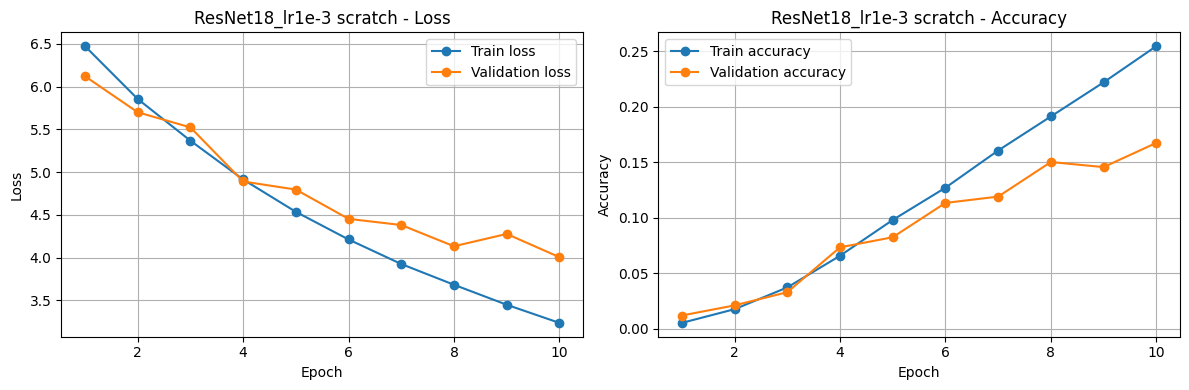

In [9]:
# Training curves are required for explaining training dynamics in the report.
curve_path = FIGURES_DIR / "resnet18lr1e-3_scratch_training_curves.png"

plot_training_history(
    resnet18_history,
    title="ResNet18_lr1e-3 scratch",
    save_path=curve_path,
)

## 10. Save Model Weights and Training History

In [ ]:
# Save local model weights for later evaluation or demo use.

model_path = MODELS_DIR / "resnet181e-3_scratch_best.pth"
history_path = RESULTS_DIR / "resnet181e-3_scratch_history.csv"

save_model_weights(resnet18_scratch, model_path)
resnet18_history.to_csv(history_path, index=False)

print("Training history saved to:", history_path)

Model saved to: e:\UNSW\9517\group work\models\resnet181e-3_scratch_best.pth
Training history saved to: e:\UNSW\9517\group work\results\resnet181e-3_scratch_history.csv


## 11. Evaluate ResNet18 Pretrained

In [11]:
# Evaluate on the validation set using report-friendly metrics.
resnet18_metrics, resnet18_predictions = evaluate_model(
    model=resnet18_scratch,
    dataloader=val_loader,
    device=device,
    class_names=train_dataset.classes,
)

resnet18_metrics_df = pd.DataFrame([{
    "model": "Resnet181e-3_scratch",
    **resnet18_metrics,
}])

display(resnet18_metrics_df)
display(resnet18_predictions.head())

,model,top1_accuracy,top5_accuracy,macro_precision,macro_recall,macro_f1,num_samples,total_inference_time_sec,inference_time_per_image_sec
0,Resnet181e-3_scratch,0.167444,0.413889,0.192122,0.167444,0.145737,9000,40.496345,0.0045


,true_label,pred_label,top1_confidence,true_class_name,pred_class_name,correct
0,0,0,0.354878,00000_Animalia_Annelida_Clitellata_Haplotaxida...,00000_Animalia_Annelida_Clitellata_Haplotaxida...,True
1,0,128,0.079786,00000_Animalia_Annelida_Clitellata_Haplotaxida...,00184_Animalia_Arthropoda_Insecta_Coleoptera_B...,False
2,0,111,0.284108,00000_Animalia_Annelida_Clitellata_Haplotaxida...,00167_Animalia_Arthropoda_Diplopoda_Spirobolid...,False
3,0,0,0.065870,00000_Animalia_Annelida_Clitellata_Haplotaxida...,00000_Animalia_Annelida_Clitellata_Haplotaxida...,True
4,0,273,0.088641,00000_Animalia_Annelida_Clitellata_Haplotaxida...,01317_Animalia_Arthropoda_Insecta_Lepidoptera_...,False


## 12. Save Evaluation Results

In [ ]:

metrics_path = RESULTS_DIR / "resnet181e-3_scratch_metrics.csv"
predictions_path = RESULTS_DIR / "resnet181e-3_scratch_predictions.csv"

resnet18_metrics_df.to_csv(metrics_path, index=False)
resnet18_predictions.to_csv(predictions_path, index=False)

print("Metrics saved to:", metrics_path)
print("Predictions saved to:", predictions_path)

Metrics saved to: e:\UNSW\9517\group work\results\resnet181e-3_scratch_metrics.csv
Predictions saved to: e:\UNSW\9517\group work\results\resnet181e-3_scratch_predictions.csv


## 13. Append Experiment Log

In [ ]:
# This module is actually not really necessary, you can just ignore it.
experiment_log = {
    "experiment_name": "ResNet18lr1e-3_scratch_initial_test",
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "model_type": "ResNet18",
    "initialisation": "ImageNet scratch",
    "pretrained": True,
    "freeze_backbone": False,
    "num_classes": num_classes,
    "num_train_images": len(train_dataset),
    "num_val_images": len(val_dataset),
    "input_image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "num_epochs": NUM_EPOCHS_RESNET18,
    "optimizer": "AdamW",
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "loss_function": "CrossEntropyLoss",
    "augmentation": "Resize, RandomHorizontalFlip, RandomRotation",
    "device": str(device),
    "best_train_acc": resnet18_history["train_acc"].max(),
    "best_val_acc": resnet18_history["val_acc"].max(),
    "final_train_acc": resnet18_history["train_acc"].iloc[-1],
    "final_val_acc": resnet18_history["val_acc"].iloc[-1],
    "final_train_loss": resnet18_history["train_loss"].iloc[-1],
    "final_val_loss": resnet18_history["val_loss"].iloc[-1],
    "top1_accuracy": resnet18_metrics["top1_accuracy"],
    "top5_accuracy": resnet18_metrics["top5_accuracy"],
    "macro_precision": resnet18_metrics["macro_precision"],
    "macro_recall": resnet18_metrics["macro_recall"],
    "macro_f1": resnet18_metrics["macro_f1"],
    "total_training_time_sec": resnet18_history["epoch_time_sec"].sum(),
    "total_inference_time_sec": resnet18_metrics["total_inference_time_sec"],
    "notes": "Initial transfer learning experiment using ImageNet-pretrained ResNet18."
}

experiment_log_path = RESULTS_DIR / "scratchlr1e-3experiment_log.csv"
updated_experiment_log = append_experiment_log(experiment_log_path, experiment_log)

display(updated_experiment_log.tail())

Experiment log saved to: e:\UNSW\9517\group work\results\scratchlr1e-3experiment_log.csv


,experiment_name,timestamp,model_type,initialisation,pretrained,freeze_backbone,num_classes,num_train_images,num_val_images,input_image_size,...,final_train_loss,final_val_loss,top1_accuracy,top5_accuracy,macro_precision,macro_recall,macro_f1,total_training_time_sec,total_inference_time_sec,notes
0,ResNet18lr1e-3_scratch_initial_test,2026-07-27 00:13:08,ResNet18,ImageNet scratch,True,False,900,45000,9000,224,...,3.237348,4.006137,0.167444,0.413889,0.192122,0.167444,0.145737,2676.578286,40.496345,Initial transfer learning experiment using Ima...
